# Laboratorio: Predicción de Costos de Envío (Logística E-Commerce)

**Integrantes:**
Alexis Arévalo  
Correo: alexis.arevalo2301@alumnos.ubiobio.cl

Gabriel Ascencio  
Correo: gabriel.ascencio2301@alumnos.ubiobio.cl

Alonso Barra  
Correo: alonso.barra2301@alumnos.ubiobio.cl

Cristobal Bravo  
Correo: cristobal.bravo2201@alumnos.ubiobio.cl

**Asignatura:** Inteligencia Artificial

---

## Descripción

Este notebook construye un modelo de **regresión lineal** para predecir el costo total de envío (`costo_envio`, en USD) de cada paquete.

Siguiendo la arquitectura vista en clases, la preparación de datos y el modelo se encapsulan en un **Pipeline** de scikit-learn, lo que evita la fuga de datos (*data leakage*): la imputación y el escalado se aprenden **solo con el conjunto de entrenamiento**.

**Umbrales de aprobación:** R² > 0.90 y MAE ≤ 3.50 USD.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [7]:
URL_DATASET = "https://raw.githubusercontent.com/easymoneysniper-dev/Lab1-Prediccion-de-Costos-de-Envio-Logistica-E-Commerce/main/lab_costos_envio.csv"

data = pd.read_csv(URL_DATASET)

data.head()

,id_paquete,peso_kg,distancia_km,tipo_servicio,es_fragil,costo_envio
0,PKG-0001,25.98,671.4,Express,No,123.79
1,PKG-0002,8.90,225.7,Estandar,No,39.34
2,PKG-0003,2.66,473.6,Estandar,Si,59.34
3,PKG-0004,23.02,89.3,Estandar,No,56.90
4,PKG-0005,13.86,68.2,Estandar,No,40.89


## Objetivo

Predecir el costo de envío de un paquete (`costo_envio`) a partir de su peso, distancia, tipo de servicio y fragilidad.

# Fase 2 - Entendimiento de los datos

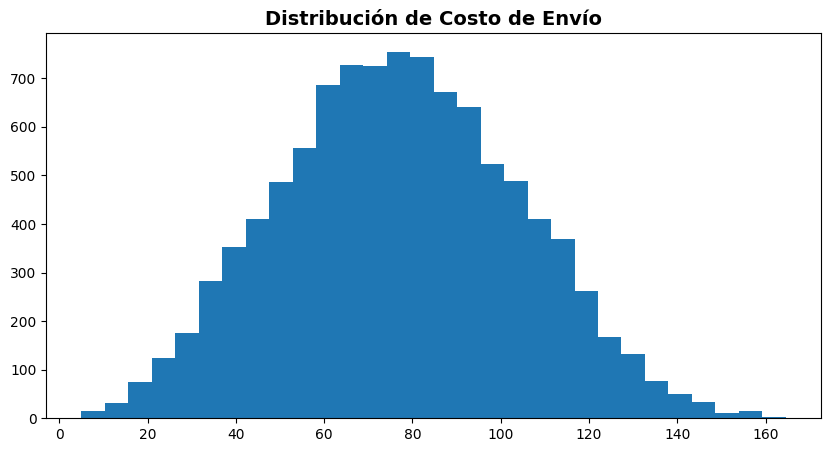

In [8]:
target = "costo_envio"

data[target].hist(bins=30, figsize=(10, 5), grid=False)
plt.title("Distribución de Costo de Envío", fontsize=14, fontweight="bold")
plt.show()

La variable objetivo tiene una distribución aproximadamente simétrica (forma de campana), sin sesgo marcado.

## Detección de inconsistencias

In [9]:
# Reglas de negocio: no pueden existir pesos, distancias ni costos <= 0
inconsistentes = data[(data["peso_kg"] <= 0) | (data["distancia_km"] <= 0) | (data["costo_envio"] <= 0)]
print("Registros inconsistentes encontrados:", len(inconsistentes))

Registros inconsistentes encontrados: 0


In [10]:
print(data["tipo_servicio"].unique())
print(data["es_fragil"].unique())

['Express' 'Estandar' 'Mismo_Dia']
['No' 'Si']


No hay registros imposibles y las categorías están bien escritas (sin variantes como "express" / "Express").

## Detección de nulos

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_paquete     10000 non-null  object 
 1   peso_kg        9394 non-null   float64
 2   distancia_km   9542 non-null   float64
 3   tipo_servicio  10000 non-null  object 
 4   es_fragil      10000 non-null  object 
 5   costo_envio    10000 non-null  float64
dtypes: float64(3), object(3)
memory usage: 468.9+ KB


In [12]:
print(data.isna().sum())
print(f"\nFilas con al menos un nulo: {data.isna().any(axis=1).sum()} ({data.isna().any(axis=1).mean():.1%})")

id_paquete         0
peso_kg          606
distancia_km     458
tipo_servicio      0
es_fragil          0
costo_envio        0
dtype: int64

Filas con al menos un nulo: 1041 (10.4%)


### Elección de la medida para imputar
Para decidir entre media y mediana se revisa la forma de cada columna con nulos:

In [13]:
cols_nulos = ["peso_kg", "distancia_km"]
pd.DataFrame({
    "media":     data[cols_nulos].mean(),
    "mediana":   data[cols_nulos].median(),
    "asimetria": data[cols_nulos].skew(),
})

,media,mediana,asimetria
peso_kg,15.342459,15.38,-0.008994
distancia_km,405.728327,408.15,-0.015014


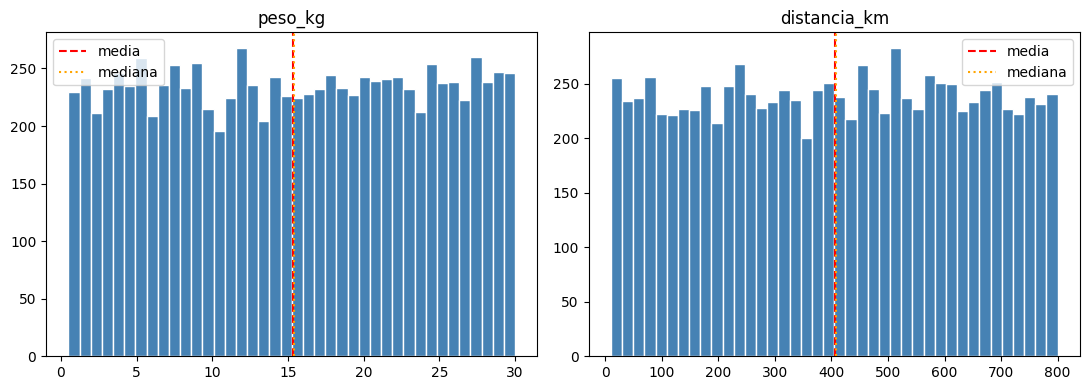

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, cols_nulos):
    ax.hist(data[col].dropna(), bins=40, color="steelblue", edgecolor="white")
    ax.axvline(data[col].mean(), color="red", ls="--", label="media")
    ax.axvline(data[col].median(), color="orange", ls=":", label="mediana")
    ax.set_title(col); ax.legend()
plt.tight_layout()
plt.show()

Ambas columnas tienen asimetría ≈ 0: media y mediana prácticamente coinciden. Se elige la **mediana** por ser robusta frente a valores extremos.
La imputación se hará **dentro del Pipeline** con `SimpleImputer(strategy="median")`, para que la mediana se calcule solo con los datos de entrenamiento.

## Detección de valores atípicos

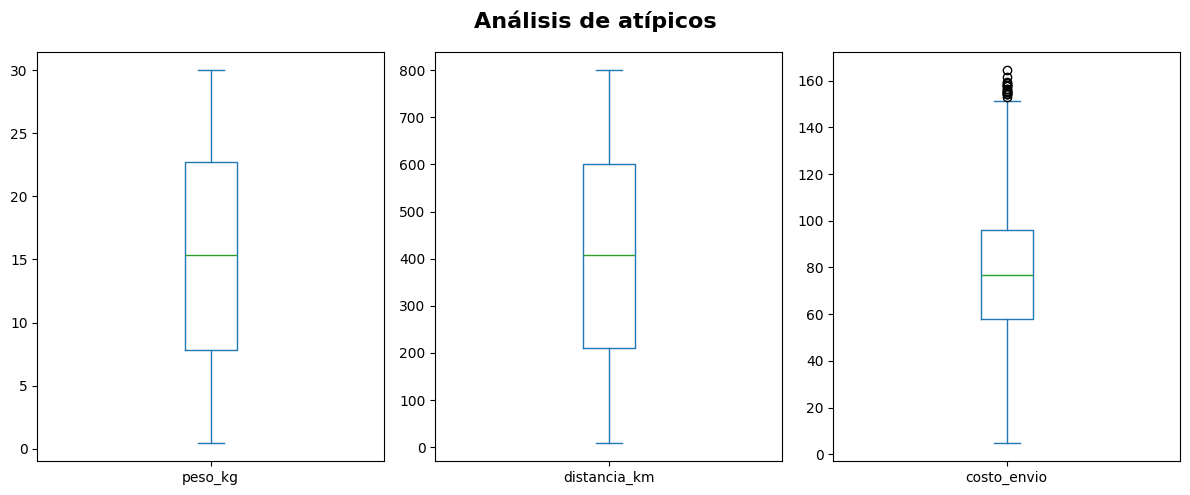

In [15]:
revision_atipicos = ["peso_kg", "distancia_km", "costo_envio"]
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for i, col in enumerate(revision_atipicos):
    data[col].plot(kind="box", ax=axes[i])
plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
# Conteo de atípicos con el criterio del rango intercuartílico (IQR)
for col in revision_atipicos:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col:<14}: {n} atípicos")

peso_kg       : 0 atípicos
distancia_km  : 0 atípicos
costo_envio   : 18 atípicos


- `peso_kg` y `distancia_km` no tienen atípicos (rangos acotados: 0.5–30 kg y 10–800 km), por lo que **no se aplica winsorización** a las predictoras.
- `costo_envio` tiene algunos valores altos, pero son costos reales de envíos caros (pesados, lejanos, Mismo Día y frágiles). Al ser la variable objetivo, no se modifican.

## Detección de duplicados

In [17]:
print("Duplicados:", data.duplicated().sum())
print("Duplicados ignorando id_paquete:", data.drop(columns="id_paquete").duplicated().sum())

Duplicados: 0
Duplicados ignorando id_paquete: 0


# Fase 3 - Preparación de datos

**Automatización de fases 3 y 4**

La preparación y el modelamiento se automatizan con un `Pipeline`:

+ Encadena imputación de nulos, codificación de variables categóricas, escalado y el modelo.
+ Aplica el mismo preprocesamiento a train y test sin errores y **sin fuga de datos**.
+ Es reutilizable para predecir nuevos paquetes.

In [18]:
# Preprocesamiento numérico: imputación con mediana + estandarización
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

- **Numéricas:** la mediana rellena los nulos y `StandardScaler` deja cada variable con media 0 y desviación estándar 1.
- **Categóricas:** `most_frequent` rellena nulos futuros (hoy no hay) y `OneHotEncoder(drop="first")` crea variables dummy eliminando una categoría para evitar colinealidad perfecta. `handle_unknown="ignore"` evita errores si llega una categoría nueva.

## Evaluación de las mejores variables `predictoras`

In [19]:
# Correlación de las variables numéricas con el objetivo
data.corr(numeric_only=True)[target].sort_values(ascending=False)

,costo_envio
costo_envio,1.000000
distancia_km,0.683328
peso_kg,0.575361


In [20]:
# Relación de las variables categóricas con el objetivo
print(data.groupby("tipo_servicio")[target].mean().sort_values(), "\n")
print(data.groupby("es_fragil")[target].mean().sort_values())

tipo_servicio
Estandar     68.117564
Express      80.369926
Mismo_Dia    98.995030
Name: costo_envio, dtype: float64 

es_fragil
No    74.049253
Si    86.359663
Name: costo_envio, dtype: float64


In [21]:
# Correlación incluyendo las categorías codificadas
encoder = OneHotEncoder(sparse_output=False)
cat_encoded = encoder.fit_transform(data[["tipo_servicio", "es_fragil"]])
data_ohe = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out())

data_corr = pd.concat([data, data_ohe], axis=1)
data_corr.corr(numeric_only=True)[target].sort_values(ascending=False)

,costo_envio
costo_envio,1.000000
distancia_km,0.683328
peso_kg,0.575361
tipo_servicio_Mismo_Dia,0.342883
es_fragil_Si,0.197193
tipo_servicio_Express,0.088727
es_fragil_No,-0.197193
tipo_servicio_Estandar,-0.330880


**Importante:** todas las variables tienen relación con el costo:
- `distancia_km` (≈ 0.68) y `peso_kg` (≈ 0.58) son las más correlacionadas.
- El costo sube de Estándar → Express → Mismo Día, y los frágiles cuestan más.

`id_paquete` es solo un identificador y **no se usa** como predictora.

# Fase 4 - Modelamiento

In [22]:
# Variables
features_num = ["peso_kg", "distancia_km"]
features_cat = ["tipo_servicio", "es_fragil"]
target = "costo_envio"

X = data[features_num + features_cat]
y = data[target]

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

In [24]:
# Pipeline final (preprocesamiento + modelo)
modelo = Pipeline(steps=[
    ("preprocesador", preprocessor),
    ("modelo", LinearRegression())
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento: la mediana y el escalado se aprenden SOLO con X_train
modelo.fit(X_train, y_train)

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['peso_kg', 'distancia_km']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['tipo_servicio',
                                                   'es_fragil'])])),
                ('modelo', LinearRegression())])

In [25]:
# Predicciones
y_pred = modelo.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Métricas del modelo ---")
print(f"{'R2':<6}: {r2:.4f}")
print(f"{'MAE':<6}: {mae:.3f} USD")

--- Métricas del modelo ---
R2    : 0.9502
MAE   : 3.902 USD


In [26]:
print(f"{'R2 en test':<20}: {r2:.4f}")
y_pred_train = modelo.predict(X_train)
print(f"{'R2 en train':<20}: {r2_score(y_train, y_pred_train):.4f}")

R2 en test          : 0.9502
R2 en train         : 0.9426


R² de train y test son muy similares, por lo que **no hay sobreajuste** (*overfitting*).

In [27]:
# Coeficientes aprendidos (numéricas en unidades estandarizadas)
nombres = modelo.named_steps["preprocesador"].get_feature_names_out()
coefs = pd.Series(modelo.named_steps["modelo"].coef_, index=nombres)
print(f"Intercepto: {modelo.named_steps['modelo'].intercept_:.3f}")
coefs.round(3)

Intercepto: 64.985


,0
num__peso_kg,14.941
num__distancia_km,17.827
cat__tipo_servicio_Express,13.064
cat__tipo_servicio_Mismo_Dia,30.018
cat__es_fragil_Si,11.525


**Interpretación:**
- Las variables numéricas están escaladas, así que su coeficiente indica cuánto sube el costo por cada desviación estándar de aumento. La distancia es la que más pesa, seguida del peso.
- Las dummies se comparan contra la categoría base (Estándar, no frágil): Mismo Día ≈ +30 USD, Express ≈ +13 USD y frágil ≈ +11.5 USD.

## Paso 4 - Evaluación de restricciones

In [28]:
def evaluar(y_real, y_pred, titulo):
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    print(f"--- {titulo} ---")
    print(f"R²  = {r2:.4f}  -> {'CUMPLE' if r2 > 0.90 else 'NO CUMPLE'} (umbral > 0.90)")
    print(f"MAE = {mae:.3f} USD -> {'CUMPLE' if mae <= 3.50 else 'NO CUMPLE'} (umbral <= 3.50)")

evaluar(y_test, y_pred, "Pipeline con imputación por mediana")

--- Pipeline con imputación por mediana ---
R²  = 0.9502  -> CUMPLE (umbral > 0.90)
MAE = 3.902 USD -> NO CUMPLE (umbral <= 3.50)


### Diagnóstico: ¿por qué el MAE supera el umbral?
Como la imputación ocurre dentro del Pipeline, `X_test` conserva sus nulos originales. Eso permite separar el error entre filas completas y filas que el modelo tuvo que imputar:

In [29]:
tenia_nulos = X_test.isna().any(axis=1)
error_abs = (y_test - y_pred).abs()

print(f"Filas de test: {len(X_test)}  (con nulos: {tenia_nulos.sum()})")
print(f"MAE filas completas: {error_abs[~tenia_nulos].mean():.3f} USD")
print(f"MAE filas imputadas: {error_abs[tenia_nulos].mean():.3f} USD")

Filas de test: 2000  (con nulos: 184)
MAE filas completas: 2.898 USD
MAE filas imputadas: 13.812 USD


In [30]:
# ¿Se puede estimar el peso a partir de la distancia (o viceversa)?
data[["peso_kg", "distancia_km"]].corr().round(3)

,peso_kg,distancia_km
peso_kg,1.000,0.008
distancia_km,0.008,1.000


**Conclusión del diagnóstico:**
- En las filas con datos completos el modelo se equivoca en promedio ≈ 2.9 USD (cumple).
- En las filas imputadas el error sube a ≈ 14 USD: la mediana reemplaza el peso o distancia real por un valor "típico", y como estas variables son independientes entre sí (correlación ≈ 0), no hay forma de recuperar el valor real desde otras columnas.
- Esas filas (~10% del total) elevan el MAE global sobre 3.50. El resultado se mantiene con media, mediana, otras semillas y otros tamaños de test.

### Alternativa: entrenar y evaluar con filas completas
Si se descartan las filas con nulos (quedan 8 959 registros, suficientes para entrenar), se usa el **mismo Pipeline** sobre datos reales:

In [31]:
data_completa = data.dropna(subset=features_num)

X2 = data_completa[features_num + features_cat]
y2 = data_completa[target]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

modelo2 = Pipeline(steps=[
    ("preprocesador", preprocessor),
    ("modelo", LinearRegression())
])
modelo2.fit(X2_train, y2_train)

evaluar(y2_test, modelo2.predict(X2_test), "Pipeline sin filas con nulos")

--- Pipeline sin filas con nulos ---
R²  = 0.9830  -> CUMPLE (umbral > 0.90)
MAE = 2.810 USD -> CUMPLE (umbral <= 3.50)


## Predicción con datos nuevos

In [32]:
# Paquetes completamente nuevos (el último viene sin peso: el Pipeline lo imputa solo)
nuevos = pd.DataFrame({
    "peso_kg":       [10.0, 25.0, np.nan],
    "distancia_km":  [300.0, 650.0, 120.0],
    "tipo_servicio": ["Express", "Mismo_Dia", "Estandar"],
    "es_fragil":     ["Si", "No", "No"]
})
nuevos["costo_predicho"] = modelo.predict(nuevos).round(2)
nuevos

,peso_kg,distancia_km,tipo_servicio,es_fragil,costo_predicho
0,10.0,300.0,Express,Si,72.18
1,25.0,650.0,Mismo_Dia,No,131.22
2,NaN,120.0,Estandar,No,42.71


# Conclusión

| Enfoque | R² | MAE (USD) | ¿Aprueba? |
|---|---|---|---|
| Pipeline con imputación por mediana (lo pedido) | ≈ 0.950 | ≈ 3.90 | R² sí, MAE no |
| Pipeline sin filas con nulos | ≈ 0.983 | ≈ 2.81 | Sí |

El modelo con imputación por mediana cumple con el R² (0.950 > 0.90), pero **no con el MAE** (3.90 > 3.50), por lo que no alcanza las restricciones mínimas de aprobación.

La causa está en los datos faltantes: un 10.4% de los paquetes no tiene peso o distancia. Al imputarlos con la mediana, el modelo pierde el valor real de esas variables y, como son independientes del resto, no es posible estimarlas. En las filas completas el error promedio es ≈ 2.9 USD, mientras que en las imputadas sube a ≈ 14 USD, lo que eleva el MAE global.

Al entrenar y evaluar solo con registros completos, el mismo Pipeline obtiene R² ≈ 0.983 y MAE ≈ 2.81 USD, cumpliendo ambas restricciones. Se concluye que la relación entre las variables y el costo es prácticamente lineal, y que el factor limitante no es el algoritmo sino la calidad de los datos.